In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    confusion_matrix,classification_report,roc_auc_score,RocCurveDisplay, roc_curve)
import matplotlib.pyplot as plt

In [6]:
train = pd.read_csv("../data/processed/train_smote.csv")
test = pd.read_csv("../data/processed/test_data.csv")
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (1582354, 48)
Test Shape : (200000, 48)


In [2]:
df = pd.read_csv("../data/processed/financial_fraud_feature_engineered.csv")
print(df.shape)


(1582354, 55)


In [7]:
# Separate Features and Target
X_train = train.drop("fraud_bool", axis=1)
y_train = train["fraud_bool"]
X_test = test.drop("fraud_bool", axis=1)
y_test = test["fraud_bool"]
print(X_train.shape)
print(X_test.shape)

(1582354, 47)
(200000, 47)


In [9]:
model = LogisticRegression(random_state=42,max_iter=1000)
model.fit(X_train, y_train)


c:\Users\dell\OneDrive\Desktop\Financial-Fraud-Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [10]:
y_pred = model.predict(X_test) #prediction
y_prob = model.predict_proba(X_test)[:,1]

In [11]:
accuracy = accuracy_score(y_test, y_pred)     #accuracy
print("Accuracy:", accuracy)

Accuracy: 0.787805


In [12]:
precision = precision_score(y_test, y_pred)        #precision
print("Precision:", precision)

Precision: 0.02889862064120278


In [13]:
recall = recall_score(y_test, y_pred)     #recall
print("Recall:", recall)

Recall: 0.5593834995466909


In [14]:
f1 = f1_score(y_test, y_pred) #F1-score
print("F1 Score:", f1)

F1 Score: 0.05495802436145812


In [15]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[156327  41467]
 [   972   1234]]


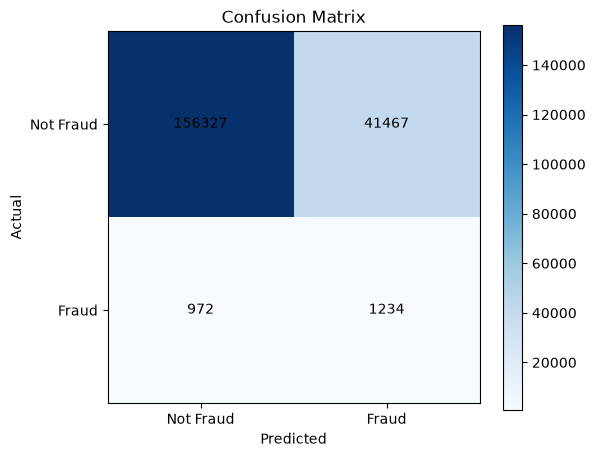

In [20]:
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1],["Not Fraud","Fraud"])
plt.yticks([0,1],["Not Fraud","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 color="black")
plt.show()

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.79      0.88    197794
           1       0.03      0.56      0.05      2206

    accuracy                           0.79    200000
   macro avg       0.51      0.67      0.47    200000
weighted avg       0.98      0.79      0.87    200000



In [23]:
#ROC-AUC-SCORE 
auc = roc_auc_score(y_test, prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.7450016863703843


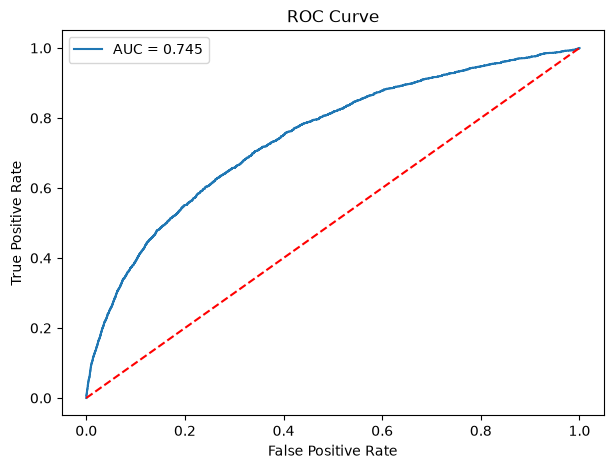

In [27]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [29]:
#feature importance
importance = pd.DataFrame({"Feature": X_train.columns,"Coefficient": model.coef_[0]})
importance = importance.sort_values(by="Coefficient",key=abs,ascending=False)
importance.head(20)

,Feature,Coefficient
22,keep_alive_session,-0.468555
25,month,-0.444457
15,phone_home_valid,-0.418721
44,device_os_2,-0.295789
26,payment_type_1,-0.289033
37,housing_status_2,-0.286773
36,housing_status_1,-0.265064
18,has_other_cards,-0.248739
16,phone_mobile_valid,-0.154961
39,housing_status_4,-0.142864


In [30]:
import joblib
joblib.dump(model,"../models/logistic_regression.pkl")
print("Model Saved Successfully.")

Model Saved Successfully.


In [31]:
importance.to_csv("../data/processed/logistic_feature_importance.csv",index=False)
print("Feature importance saved.")

Feature importance saved.


In [32]:
print("Logistic Regression Summary")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Logistic Regression Summary
Accuracy  : 0.7878
Precision : 0.0289
Recall    : 0.5594
F1 Score  : 0.0550
ROC-AUC   : 0.7450


## Summary

• Loaded the feature-engineered fraud detection dataset.
• Split the dataset into training and testing sets.
• Trained a Logistic Regression classifier.
• Generated predictions on the test data.
• Evaluated model performance using Accuracy, Precision, Recall, F1-score, Confusion Matrix,  Classification Report, and ROC-AUC score.
• Visualized the ROC curve.
• Analyzed feature coefficients to understand feature importance.
• Saved the trained Logistic Regression model for future use.